In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [24]:
df = pd.read_csv("loan_approval_data.csv")

In [25]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# handle missing values

In [44]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [45]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])


cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

ValueError: at least one array or dtype is required

In [ ]:
df

In [ ]:
df.isnull().sum()

# EDA -- Explloratory data analysis

Text(0.5, 1.0, ' Is loan approved')

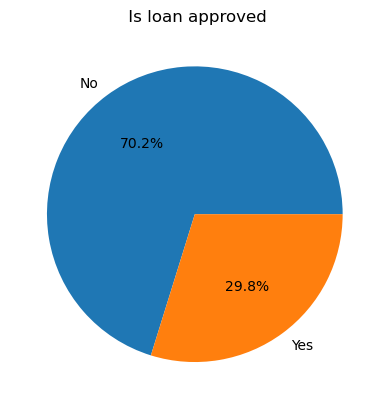

In [46]:
# How balance our classes are?
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels = ["No","Yes"],autopct = "%1.1f%%")
plt.title(" Is loan approved")

In [47]:
#Analzie categories
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

KeyError: 'Gender'

In [ ]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

In [ ]:
# analize income
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

In [ ]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

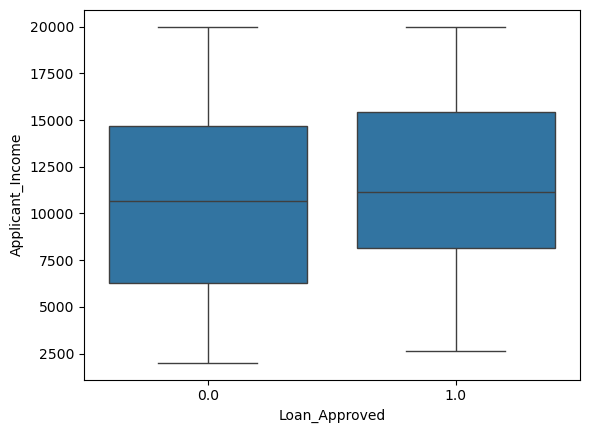

In [48]:
# Outlier --> Boxplot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)


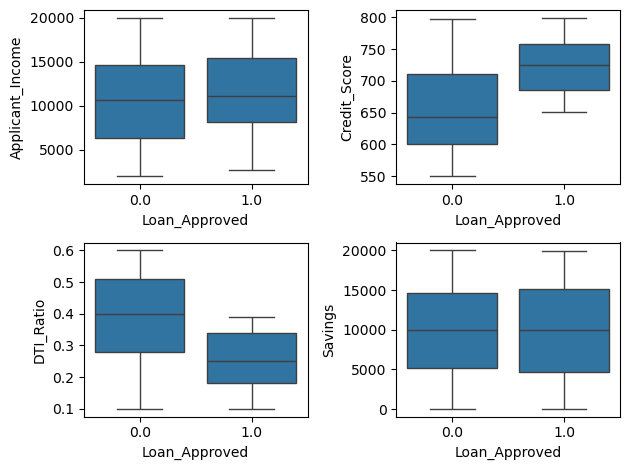

In [49]:
fig,axes = plt.subplots(2, 2)

sns.boxplot(ax = axes[0,0], data = df, x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = df, x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0], data = df, x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = df, x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Loan_Approved', ylabel='Age'>

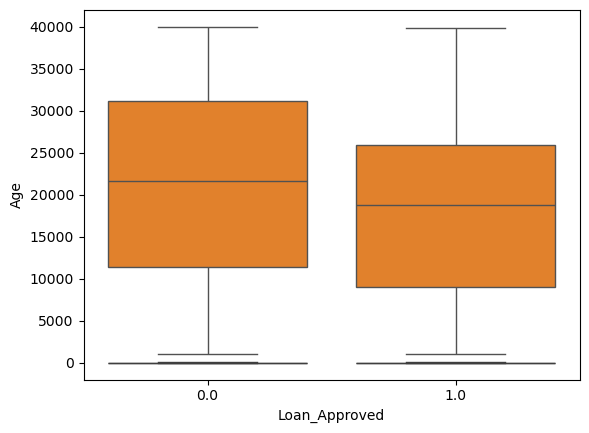

In [50]:
sns.boxplot( data = df, x = "Loan_Approved",y = "Age")
sns.boxplot( data = df, x = "Loan_Approved",y = "Loan_Amount")

<Axes: xlabel='Credit_Score', ylabel='Count'>

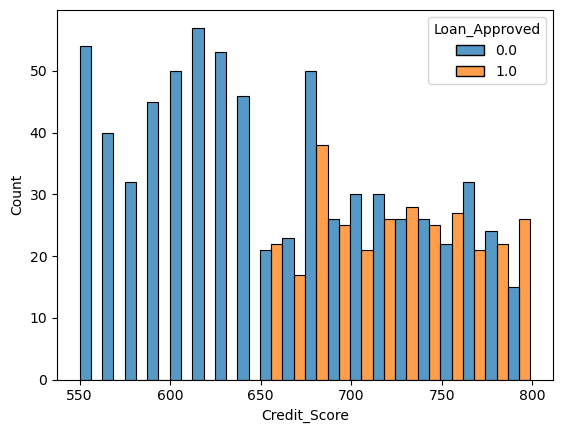

In [51]:
# loan approved with credit score
sns.histplot(
    data = df,
    hue = "Loan_Approved",
    x = "Credit_Score",
    bins = 20,
    multiple = "dodge"
)

In [56]:
# Remove applicant Id
df = df.drop("Applicant_ID",axis=1)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Feature Encoding

In [58]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [61]:
cols = ["Employment_Status","Marital_Status","Gender","Property_Area","Loan_Purpose","Employer_Category"]

ohe  = OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols),index = df.index)
df =pd.concat([df.drop(columns = cols),encoded_df],axis = 1)

In [62]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap